In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('penguins.csv')
df.head()

,speciesName,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,Adelie,39.1,18.7,181,3750
1,Adelie,39.5,17.4,186,3800
2,Adelie,40.3,18.0,195,3250
3,Adelie,36.7,19.3,193,3450
4,Adelie,39.3,20.6,190,3650


In [2]:
# Standard Scaling of data

scaled_df = df[["bill_length_mm","bill_depth_mm","flipper_length_mm","body_mass_g"]]

for i in scaled_df.columns:
    scaled_df[i] = (scaled_df[i] - scaled_df[i].mean())/scaled_df[i].std()


C:\Users\ayray\AppData\Local\Temp\ipykernel_22336\4015474450.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  scaled_df[i] = (scaled_df[i] - scaled_df[i].mean())/scaled_df[i].std()


In [3]:
scaled_df.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,-0.883205,0.784300,-1.416272,-0.563317
1,-0.809939,0.126003,-1.060696,-0.500969
2,-0.663408,0.429833,-0.420660,-1.186793
3,-1.322799,1.088129,-0.562890,-0.937403
4,-0.846572,1.746426,-0.776236,-0.688012


# Factor Analysis

In [4]:
from sklearn.decomposition import FactorAnalysis

fa = FactorAnalysis().fit(scaled_df)

factors_df = pd.DataFrame(fa.components_,columns=scaled_df.columns)

In [5]:
print(factors_df)

   bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
0        0.669078      -0.564385           0.873709     0.838500
1        0.175562       0.233976          -0.010952     0.012441
2        0.000000      -0.000000          -0.000000    -0.000000
3        0.000000      -0.000000          -0.000000     0.000000


above are the default factors given to obtain Xdash, X_dash2 etc

In [6]:
fa = FactorAnalysis(n_components=2).fit(scaled_df)

FA_fit= fa.fit_transform(scaled_df)
FA_fit[0:5,:]

array([[-1.31801089,  0.0606314 ],
       [-0.97288664, -0.40950738],
       [-0.52957234, -0.06888013],
       [-0.68368734,  0.38981206],
       [-0.8570299 ,  1.06343239]])

In [7]:
FAs_df = pd.DataFrame(data = FA_fit , 
        columns = ['FA1', 'FA2'])
FAs_df['Species'] = df.speciesName.values
FAs_df.head()

,FA1,FA2,Species
0,-1.318011,0.060631,Adelie
1,-0.972887,-0.409507,Adelie
2,-0.529572,-0.068880,Adelie
3,-0.683687,0.389812,Adelie
4,-0.857030,1.063432,Adelie


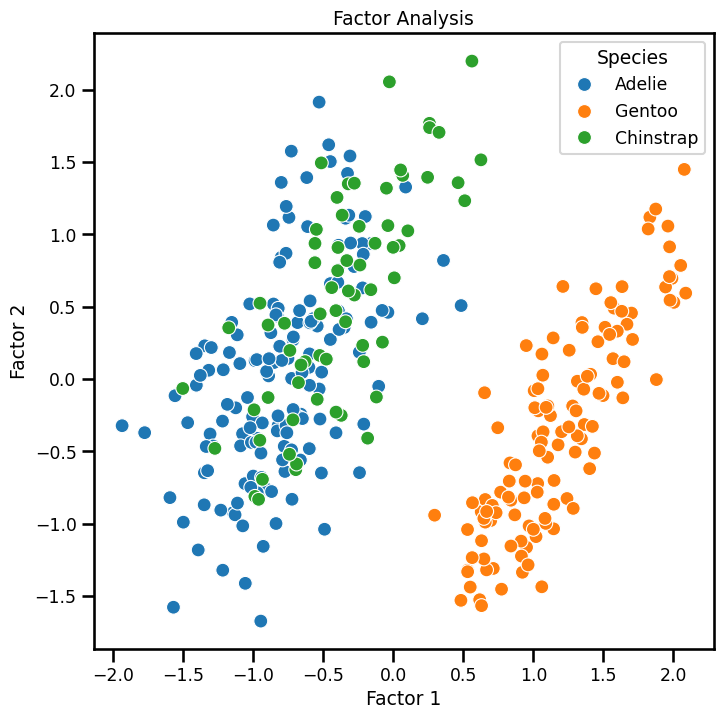

In [8]:
plt.figure(figsize=(8,8))
with sns.plotting_context("talk",font_scale=0.75):
    sns.scatterplot(x="FA1", y="FA2",
                    data=FAs_df, 
                    hue="Species",
                    s=100)
    plt.xlabel("Factor 1")
    plt.ylabel("Factor 2")
    plt.title("Factor Analysis")

# Principal Component Analysis

In [9]:
from sklearn.decomposition import PCA

pca = PCA()
pca = pca.fit(scaled_df)

display(pca.explained_variance_ratio_) 
# this shows the amount of variance explained by each principal component, First being PC1

array([0.68843878, 0.19312919, 0.09130898, 0.02712305])

The first two principal components are summing up to more than 88% of the variance in the data.

Thus taking 2 components as hyperparameters and getting the principal components should suffice

In [10]:
pca_fit = PCA(n_components=2).fit_transform(scaled_df) # n_components cannot be greater than the no. of features in the data

PCs_df = pd.DataFrame(data = pca_fit , 
        columns = ['PC1', 'PC2'])
PCs_df['Species'] = df.speciesName.values
PCs_df.head()

,PC1,PC2,Species
0,-1.840748,0.047632,Adelie
1,-1.304850,-0.427722,Adelie
2,-1.367178,-0.154250,Adelie
3,-1.876078,-0.002045,Adelie
4,-1.908951,0.827996,Adelie


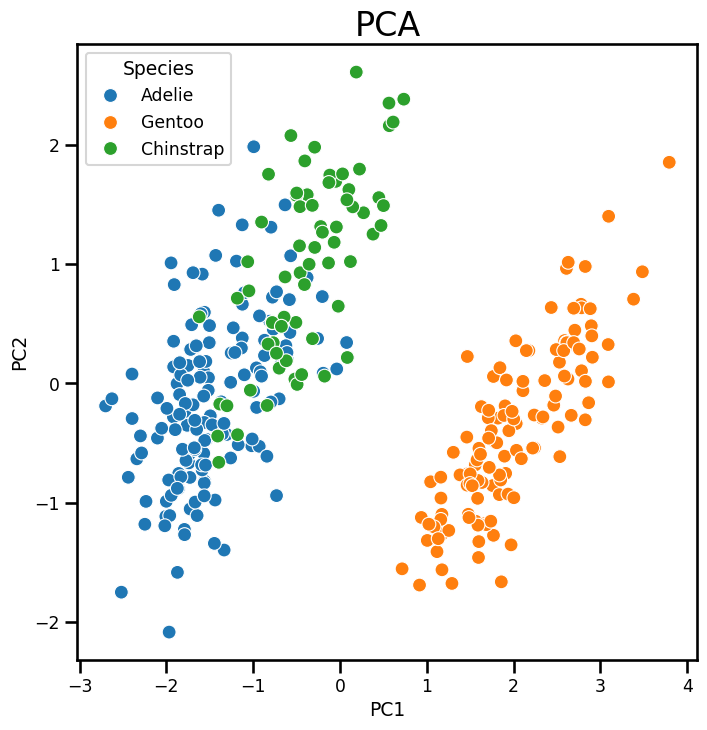

In [11]:
plt.figure(figsize=(8,8))
with sns.plotting_context("talk",font_scale=0.75):
    sns.scatterplot(x="PC1", y="PC2",
                    data=PCs_df, 
                    hue="Species",
                    s=100)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("PCA", size=24)

# Independent Component Analysis

In [12]:
from sklearn.decomposition import FastICA

ica = FastICA(n_components=2) # take n_components as same as PCA
ica_fit = ica.fit_transform(scaled_df)

ICs_df = pd.DataFrame(data = ica_fit , 
        columns = ['IC1', 'IC2'])
ICs_df['Species'] = df.speciesName.values
ICs_df.head()


,IC1,IC2,Species
0,-0.416564,-1.031250,Adelie
1,-0.772649,-0.510523,Adelie
2,-0.505545,-0.675335,Adelie
3,-0.476892,-1.026870,Adelie
4,0.373380,-1.441474,Adelie


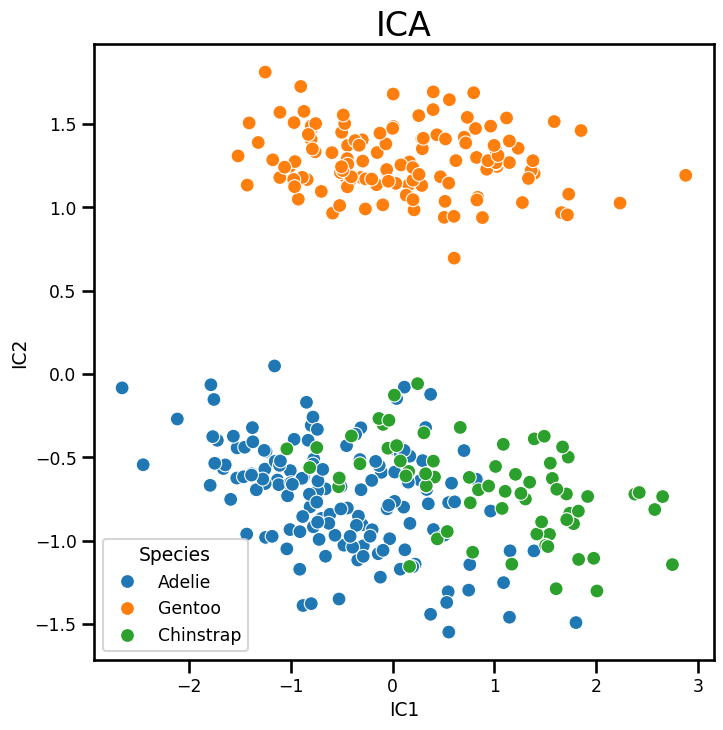

In [13]:
plt.figure(figsize=(8,8))
with sns.plotting_context("talk",font_scale=0.75):
    sns.scatterplot(x="IC1", y="IC2",
                    data=ICs_df, 
                    hue="Species",
                    s=100)
    plt.xlabel("IC1")
    plt.ylabel("IC2")
    plt.title("ICA", size=24)

# UMAP

In [14]:
# !pip install umap-learn
# !pip install umap


[notice] A new release of pip is available: 24.0 -> 24.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
import umap

umap = umap.UMAP()
umap_fit = umap.fit_transform(scaled_df)

UMAP_df = pd.DataFrame(data = umap_fit , 
        columns = ['U1', 'U2'])
UMAP_df['Species'] = df.speciesName.values
UMAP_df.head()

,U1,U2,Species
0,8.671548,6.406357,Adelie
1,8.345536,7.704693,Adelie
2,7.706962,8.120022,Adelie
3,7.514735,5.564888,Adelie
4,7.935069,4.340989,Adelie


In [22]:
umap_fit

array([[ 8.671548  ,  6.406357  ],
       [ 8.345536  ,  7.704693  ],
       [ 7.7069616 ,  8.120022  ],
       [ 7.5147347 ,  5.5648885 ],
       [ 7.9350686 ,  4.3409886 ],
       [ 8.197258  ,  7.3932266 ],
       [ 9.171582  ,  4.2721167 ],
       [ 6.8144827 ,  6.7827277 ],
       [ 8.62997   ,  3.9589608 ],
       [ 6.9921055 ,  8.057862  ],
       [ 8.106605  ,  7.3909473 ],
       [ 8.258834  ,  7.9806848 ],
       [ 7.966328  ,  4.2742105 ],
       [ 7.74839   ,  4.48099   ],
       [ 7.585361  ,  7.1097436 ],
       [ 7.6789684 ,  5.723569  ],
       [ 8.787703  ,  3.8630927 ],
       [ 7.2710614 ,  6.848037  ],
       [ 8.651343  ,  3.8260107 ],
       [ 8.157459  ,  6.7639885 ],
       [ 8.233344  ,  6.611421  ],
       [ 7.3523936 ,  5.2444434 ],
       [ 8.3037195 ,  6.9532833 ],
       [ 8.178535  ,  7.550494  ],
       [ 7.318035  ,  5.424945  ],
       [ 8.725209  ,  6.490169  ],
       [ 8.181957  ,  7.990791  ],
       [ 8.139019  ,  6.6581283 ],
       [ 8.834713  ,

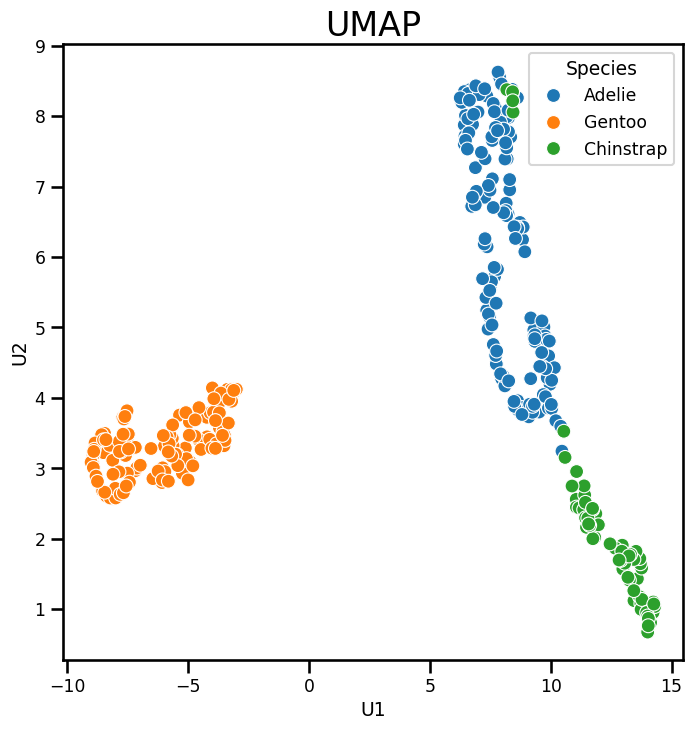

In [21]:
plt.figure(figsize=(8,8))
with sns.plotting_context("talk",font_scale=0.75):
    sns.scatterplot(x="U1", y="U2",
                    data=UMAP_df, 
                    hue="Species",
                    s=100)
    plt.xlabel("U1")
    plt.ylabel("U2")
    plt.title("UMAP", size=24)